# Sérsic modelling of BCG and ICL components from IFU data

In [ ]:
import astrophot as ap
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import fits

In [ ]:
# If GPU is not available
# ap.AP_config.ap_device = "cpu"

In [ ]:
path = Path("~/data/ifu/2025-06-23/").expanduser()

In [ ]:
def plot_data_model_residual(
    target, model, mask, limits=(200, 480, 100, 275), weight=True
):
    data = target.data.cpu()
    model = model()
    model_image = model.data.cpu()
    model_image_binned = model.unbinned_data.cpu()
    if weight:
        weight_image = target.weight.cpu()
    model_image = model_image.detach().cpu().numpy()
    ncol = 5 if weight else 4
    fig, ax = plt.subplots(
        1, ncol, figsize=(3 * ncol, 4), sharex=True, sharey=True, layout="compressed"
    )
    vmax = 0.5 * np.nanmax(data)
    vmin = -0.5 * vmax
    ax[0].imshow(np.where(mask, np.nan, data), origin="lower", vmin=vmin, vmax=vmax)
    ax[1].imshow(model_image, origin="lower", vmin=vmin, vmax=vmax)
    ax[2].imshow(model_image_binned, origin="lower", vmin=vmin, vmax=vmax)
    ax[3].imshow(
        np.where(mask, np.nan, data - model_image_binned),
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    if weight:
        ax[4].imshow(weight_image, origin="lower")
    if limits is not None:
        ax[0].axis(limits)
    for a in ax:
        a.axvline(320.6, color="white", lw=0.5)
        a.axhline(181.1, color="white", lw=0.5)

In [ ]:
def get_data(filename):
    data = np.load(path / filename)
    return data


bins = np.load(path / "voronoi_mask_SN_150.npy")
bcg_data = get_data("BCG_SB_map.npy")
icl_data = get_data("ICL_SB_map.npy")

In [ ]:
output_path = path / "outputs/"
output_path.mkdir(exist_ok=True)
fits.writeto(output_path / "bcg_data.fits", bcg_data, overwrite=True)
fits.writeto(output_path / "icl_data.fits", icl_data, overwrite=True)

In [ ]:
bcg_mask = ~np.isfinite(bcg_data)
icl_mask = ~np.isfinite(icl_data)

In [ ]:
cm = mpl.cm.Dark2
seg_cmap = mpl.colors.ListedColormap(
    np.tile(cm.colors, (int(np.ceil(np.nanmax(bins) / cm.N)), 1))
)

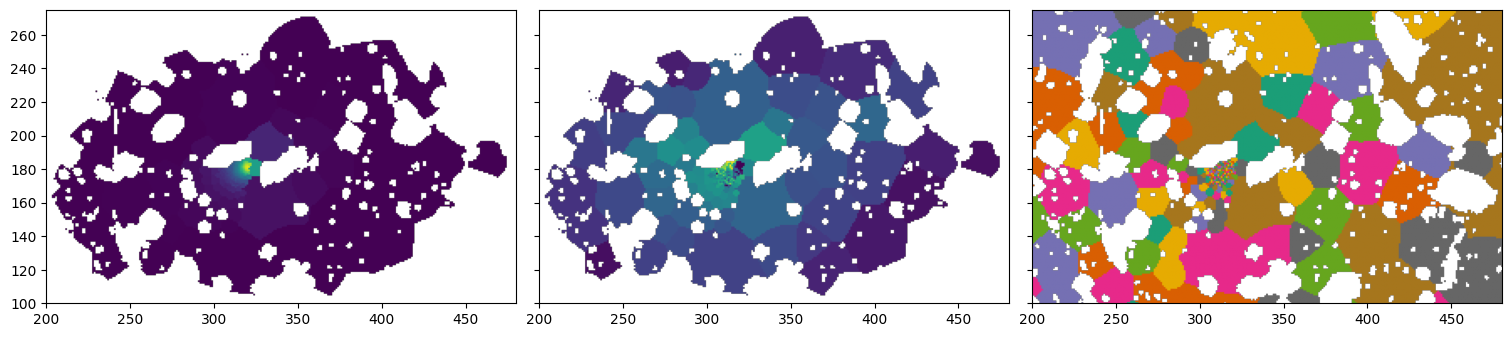

In [ ]:
fig, ax = plt.subplots(
    1, 3, figsize=(15, 5), sharex=True, sharey=True, layout="compressed"
)
ax[0].imshow(bcg_data, origin="lower", vmin=0, vmax=30)
ax[1].imshow(icl_data, origin="lower", vmin=0, vmax=3)
bins
ax[2].imshow(bins, origin="lower", cmap=seg_cmap)
ax[0].axis((200, 480, 100, 275));

In [ ]:
bcg_initial_params = {
    "center": [320, 180],
    "q": 0.6,
    "PA": 90 * np.pi / 180,
    "n": 2.0,
    "Re": 5.0,
    "Ie": 1.0,
}

## Binned fit with weights from component fraction

### Test

In [ ]:
test_params = {
    "center": [319, 179],
    "q": 0.7,
    "PA": 90 * np.pi / 180,
    "n": 1.2,
    "Re": 40.0,
    "Ie": 0.5,
}

In [ ]:
test_target = ap.image.Target_Image(
    data=np.zeros_like(bcg_data), mask=bcg_mask, bins=bins, pixelscale=1
)
test_model = ap.models.AstroPhot_Model(
    name="test_truth",
    model_type="sersic galaxy model",
    parameters=test_params,
    target=test_target,
)
test_model.initialize()

In [ ]:
test_data = test_model.sample().data.cpu()
test_noise = np.random.normal(size=test_data.shape)
test_data += test_noise

In [ ]:
test_target = ap.image.Target_Image(
    data=test_data, mask=bcg_mask, bins=bins, pixelscale=1
)
test_data_binned = test_target.unbinned_data.cpu()
test_target = ap.image.Target_Image(
    data=test_data_binned, mask=bcg_mask, bins=bins, pixelscale=1
)

In [ ]:
test_fit_model = ap.models.AstroPhot_Model(
    name="test_fit",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=test_target,
)
test_fit_model.initialize()

In [ ]:
test_result = ap.fit.LM(test_fit_model).fit()
test_result.update_uncertainty()

In [ ]:
print(test_fit_model.parameters)
print(test_model.parameters)

test_fit:
center: [319.0983512972398, 179.0361519100943] +- [0.1636055078754446, 0.08702978558880338] [arcsec]
q: 0.6974329523760192 +- 0.023172275432866346 [b/a], limits: (0.0, 1.0)
PA: 1.5892005495676962 +- 0.05029315234914499 [radians], limits: (0.0, 3.141592653589793), cyclic
n: 1.2463148820577976 +- 0.04866375077809229 [none], limits: (0.36, 8.0)
Re: 41.86079662916013 +- 3.0333476769592345 [arcsec], limits: (0.0, None)
Ie: 0.47241512793295637 +- 0.03378458191576618 [log10(flux/arcsec^2)]
test_truth:
center: [319.0, 179.0] +- [0.1, 0.1] [arcsec]
q: 0.7 +- 0.03 [b/a], limits: (0.0, 1.0)
PA: 1.5707963267948966 +- 0.06 [radians], limits: (0.0, 3.141592653589793), cyclic
n: 1.2 +- 0.05 [none], limits: (0.36, 8.0)
Re: 40.0 [arcsec], limits: (0.0, None)
Ie: 0.5 [log10(flux/arcsec^2)]


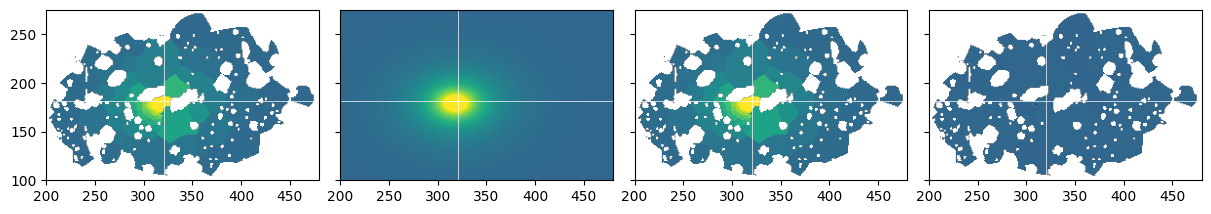

In [ ]:
plot_data_model_residual(
    test_target,
    test_fit_model,
    bcg_mask,
    weight=False,
)

### Fit the BCG

In [ ]:
total = bcg_data + icl_data
bcg_weight = bcg_data / total
bcg_weight = np.clip(bcg_weight, 1e-6, 1 - 1e-6)
icl_weight = 1 - bcg_weight

# scale weight to reflect expected variance
voronoi_snr = 150
total_noise = np.nanmedian(total) / voronoi_snr
total_weight = 1 / total_noise**2
bcg_weight *= total_weight
icl_weight *= total_weight

In [ ]:
bcg_target = ap.image.Target_Image(
    data=bcg_data, mask=bcg_mask, weight=bcg_weight, bins=bins, pixelscale=1
)

In [ ]:
# check binning is correct
diff = bcg_target.unbinned_data.cpu() - bcg_target.data.cpu()
diff = diff[diff.isfinite()]
np.allclose(diff, 0)

True

In [ ]:
bcg_model = ap.models.AstroPhot_Model(
    name="bcg",
    model_type="sersic galaxy model",
    parameters=bcg_initial_params,
    target=bcg_target,
)
bcg_model.initialize()

In [ ]:
bcg_result = ap.fit.LM(bcg_model).fit()
bcg_result.update_uncertainty()

In [ ]:
bcg_model.parameters

bcg (id-140553442706160, branch node):
  center (id-140553442715232): [320.8949668397184, 181.43022235099878] +- [0.0005319202825200972, 0.0003790366837011459] [arcsec]
  q (id-140553447723504): 0.9544585087951719 +- 0.00012365444816513202 [b/a], limits: (0.0, 1.0)
  PA (id-140553443890032): 1.3445953329818878 +- 0.0018397581204044257 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140553443475968): 0.9821633618111731 +- 0.0001650858384001023 [none], limits: (0.36, 8.0)
  Re (id-140553544468336): 11.67890559026532 +- 0.002324097003119672 [arcsec], limits: (0.0, None)
  Ie (id-140555259400784): 0.8156997726667823 +- 0.00010851225341937623 [log10(flux/arcsec^2)]

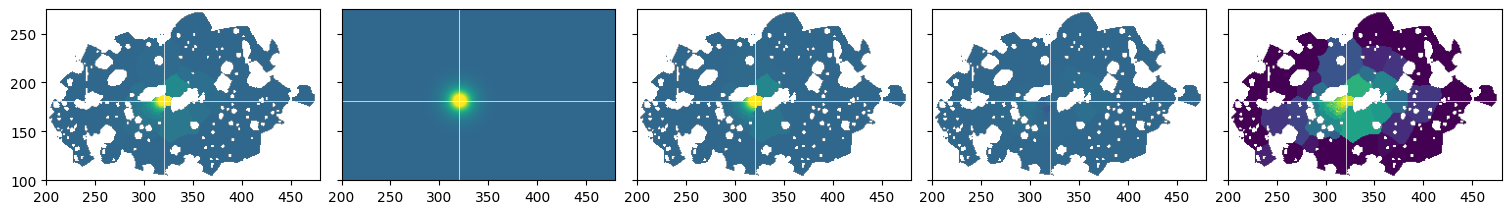

In [ ]:
plot_data_model_residual(bcg_target, bcg_model, bcg_mask)

### Fit the ICL

In [ ]:
icl_target = ap.image.Target_Image(
    data=icl_data, mask=icl_mask, weight=icl_weight, bins=bins, pixelscale=1
)

In [ ]:
def fit_icl(fixed_centre=None):
    icl_initial_params = {
        "center": [320, 180],
        "q": 0.6,
        "PA": 90 * np.pi / 180,
        "n": 2.0,
        "Re": 20.0,
        "Ie": 0.5,
    }

    if fixed_centre is not None:
        icl_initial_params.update(
            {
                "center": {
                    "value": fixed_centre.parameters["center"].value,
                    "locked": True,
                }
            }
        )

    icl_model = ap.models.AstroPhot_Model(
        name="icl",
        model_type="sersic galaxy model",
        parameters=icl_initial_params,
        target=icl_target,
    )
    icl_model.initialize()

    icl_result = ap.fit.LM(icl_model).fit()
    icl_result.update_uncertainty()

    plot_data_model_residual(
        icl_target,
        icl_model,
        icl_mask,
    )
    return icl_model.parameters

icl (id-140553442134208, branch node):
  center (id-140553442140544): [313.203851005269, 185.37464696743768] +- [0.03791588766200685, 0.04101907795234576] [arcsec]
  q (id-140553441698224): 0.6148447208738848 +- 0.0019282122356713536 [b/a], limits: (0.0, 1.0)
  PA (id-140553443120848): 1.7806935295789825 +- 0.0028816465291116498 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140553443919152): 1.4363220706876758 +- 0.005127623544231211 [none], limits: (0.36, 8.0)
  Re (id-140553441698032): 169.00958557535114 +- 1.01539846284347 [arcsec], limits: (0.0, None)
  Ie (id-140553443117392): -0.646403358857651 +- 0.0032272114660215345 [log10(flux/arcsec^2)]

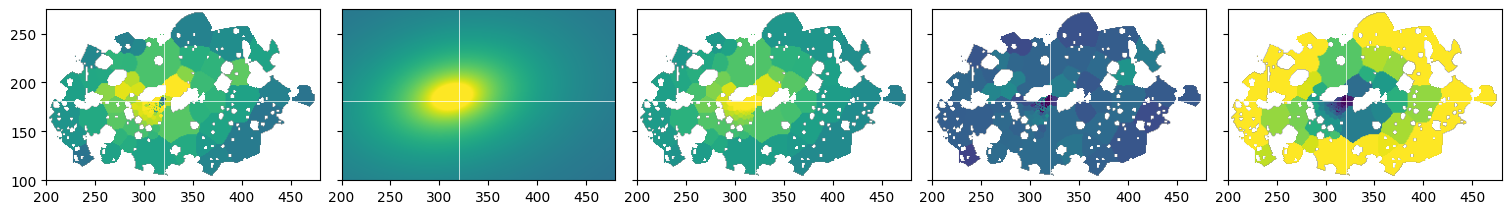

In [ ]:
fit_icl()

icl (id-140553443889552, branch node):
  center (id-140553438148080): [320.8949668397184, 181.43022235099878] +- [0.1, 0.1] [arcsec], locked
  q (id-140553439968336): 0.5266439785574777 +- 0.001293417399954829 [b/a], limits: (0.0, 1.0)
  PA (id-140553438141504): 1.5530032977026726 +- 0.0017121039905781063 [radians], limits: (0.0, 3.141592653589793), cyclic
  n (id-140553438144192): 0.9566809961976694 +- 0.0029254912772000517 [none], limits: (0.36, 8.0)
  Re (id-140553440474800): 107.59223101577255 +- 0.4050558722782919 [arcsec], limits: (0.0, None)
  Ie (id-140553440225104): -0.3359647248543155 +- 0.0019826438471590626 [log10(flux/arcsec^2)]

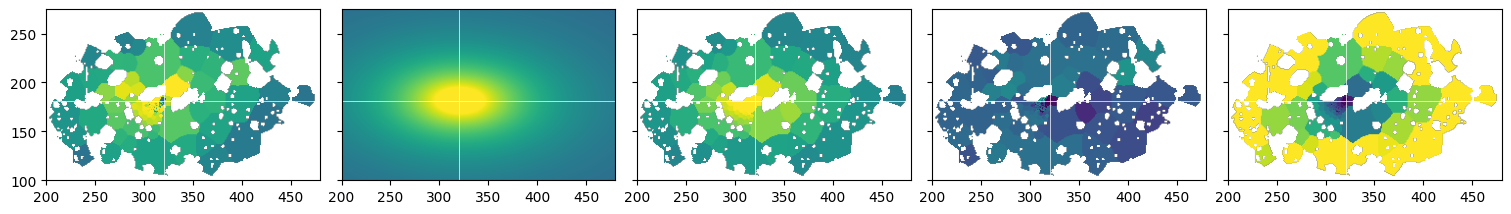

In [ ]:
fit_icl(fixed_centre=bcg_model)